In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [2]:
# Chargement des données
customers = pd.read_csv('../DATA/df_customers.csv', header=0, index_col=0)
events = pd.read_csv('../DATA/df_events.csv', header=0, index_col=0)
sales = pd.read_csv('../DATA/df_sales.csv', header=0, index_col=0)

# Conversion des ID en format string
customers['ID'] = customers['ID'].astype(str)
sales['id_client'] = sales['id_client'].astype(str)

# Consersion des dates en format datetime
sales['date_utilisation'] = pd.to_datetime(sales['date_utilisation'])
events['begin_on'] = pd.to_datetime(events['begin_on'])
sales['date_creation'] = pd.to_datetime(sales['date_creation'])
customers['DDN'] = pd.to_datetime(customers['DDN'])
customers['DDN'] = pd.to_datetime(customers['DDN'])

In [3]:
customers.head()

,ID,sexe,DDN,sub,sub_notif,sub_newsletter
0,0,1,NaT,NaN,NaN,NaN
1,1,M,NaT,NaN,NaN,NaN
2,2,M,2003-05-25,NaN,NaN,NaN
3,3,0,NaT,NaN,NaN,1.0
4,4,M,2003-02-08,NaN,NaN,NaN


In [4]:
events.head()

,ID,begin_on,ville,Source,Lieu,Type_Lieu
0,1,2022-10-15,Lille,CRM221014,Salle Rouge,Salle
1,2,2022-11-26,Lille,CRM221126,Salle Rouge,Salle
2,3,2022-12-31,Lille,CRM221231,Salle Rouge,Salle
3,4,2023-02-18,Lille,CRM230218,Salle Rouge,Salle
4,5,2023-05-05,Lille,CRM230505,Salle Verte,Club


In [5]:
sales.head()

,id_billet,commande,date_creation,id_client,prix,date_utilisation,source
0,0,0,2024-05-20 23:38:17,3753,7.99,2024-06-08 01:09:18,CRM240608
1,1,1,2024-05-21 01:11:17,1323,7.99,2024-06-08 01:55:08,CRM240608
2,2,2,2024-05-21 01:27:30,3743,7.99,2024-06-08 00:11:39,CRM240608
3,3,3,2024-05-21 01:29:29,1432,7.99,2024-06-08 00:11:47,CRM240608
4,4,4,2024-05-21 01:35:59,4657,7.99,2024-06-08 00:30:54,CRM240608


In [6]:
# fusion entre sales et custoers
sales_events = pd.merge(left=sales, right=events, left_on="source", right_on='Source')
sales_events.head()
ville_counts = sales_events['ville'].value_counts()
ville_counts.head()
#plt.pie(ville_counts, labels=ville_counts.index, autopct='%1.1f%%')


ville
Lille     11337
Paris      1943
Nantes      505
Name: count, dtype: int64

In [7]:
#customers.rename(columns={'ID': 'id_client'}, inplace=True) renommage d'un nom de colonne
data = pd.merge(left=sales_events, right=customers, left_on='id_client', right_on='ID')
print(data.shape)
data = data.drop(['ID_x', 'ID_y'], axis=1)
data.head()

(13703, 19)


,id_billet,commande,date_creation,id_client,prix,date_utilisation,source,begin_on,ville,Source,Lieu,Type_Lieu,sexe,DDN,sub,sub_notif,sub_newsletter
0,0,0,2024-05-20 23:38:17,3753,7.99,2024-06-08 01:09:18,CRM240608,2024-06-07,Lille,CRM240608,Salle Verte,Club,F,2005-05-19,NaN,NaN,NaN
1,1,1,2024-05-21 01:11:17,1323,7.99,2024-06-08 01:55:08,CRM240608,2024-06-07,Lille,CRM240608,Salle Verte,Club,F,2003-01-01,0.0,0.0,0.0
2,2,2,2024-05-21 01:27:30,3743,7.99,2024-06-08 00:11:39,CRM240608,2024-06-07,Lille,CRM240608,Salle Verte,Club,F,NaT,NaN,NaN,NaN
3,3,3,2024-05-21 01:29:29,1432,7.99,2024-06-08 00:11:47,CRM240608,2024-06-07,Lille,CRM240608,Salle Verte,Club,F,2005-01-01,0.0,0.0,0.0
4,4,4,2024-05-21 01:35:59,4657,7.99,2024-06-08 00:30:54,CRM240608,2024-06-07,Lille,CRM240608,Salle Verte,Club,NaN,2001-01-01,0.0,0.0,0.0


In [8]:
# Traitement des valeurs manquantes
data.notnull().mean()

id_billet           1.000000
commande            1.000000
date_creation       1.000000
id_client           1.000000
prix                1.000000
date_utilisation    0.799241
source              1.000000
begin_on            1.000000
ville               1.000000
Source              1.000000
Lieu                1.000000
Type_Lieu           1.000000
sexe                0.872510
DDN                 0.856820
sub                 0.356053
sub_notif           0.356053
sub_newsletter      0.380793
dtype: float64

In [9]:
data.dtypes

id_billet                    int64
commande                     int64
date_creation       datetime64[ns]
id_client                   object
prix                       float64
date_utilisation    datetime64[ns]
source                      object
begin_on            datetime64[ns]
ville                       object
Source                      object
Lieu                        object
Type_Lieu                   object
sexe                        object
DDN                 datetime64[ns]
sub                        float64
sub_notif                  float64
sub_newsletter             float64
dtype: object

In [10]:
data.isnull().sum()

id_billet              0
commande               0
date_creation          0
id_client              0
prix                   0
date_utilisation    2751
source                 0
begin_on               0
ville                  0
Source                 0
Lieu                   0
Type_Lieu              0
sexe                1747
DDN                 1962
sub                 8824
sub_notif           8824
sub_newsletter      8485
dtype: int64

In [11]:
# # Remplacement des valeurs manquantes
# for nom_colonne in data.columns:
#     if data[nom_colonne].isnull().sum() > 0:
#         if data[nom_colonne].dtype in [np.float64, np.int64]:
#             data[nom_colonne] = (data.groupby("ville")[nom_colonne].transform(lambda x: x.fillna(x.median())))
#         else:
#             data[nom_colonne] = (data.groupby("ville")[nom_colonne].transform(lambda x: x.fillna(x.mode().iloc[0] if not x.mode().empty else np.nan)))

In [12]:
### Date utilisation
# Calcule des médianes groupées
data['date_utilisation'] = data['date_utilisation'].fillna(
    data.groupby('source')['date_utilisation']
           .transform(lambda x: x.dropna().median())
)

### Sexe
data['sexe']=data['sexe'].replace({'1':'F', '0':'M'}) # Formatage des données pour n'avoir que 2 modalités
data['sexe']=data['sexe'].fillna(value=data['sexe'].mode()[0])

### DDN
data['DDN']=data['DDN'].fillna(data['DDN'].median())

### sub, sub_notif, sub_newsletter
data['sub']=data['sub'].fillna(0)
data['sub_notif']=data['sub_notif'].fillna(0)
data['sub_newsletter']=data['sub_newsletter'].fillna(0)

In [13]:
data.head(20)

,id_billet,commande,date_creation,id_client,prix,date_utilisation,source,begin_on,ville,Source,Lieu,Type_Lieu,sexe,DDN,sub,sub_notif,sub_newsletter
0,0,0,2024-05-20 23:38:17,3753,7.99,2024-06-08 01:09:18,CRM240608,2024-06-07,Lille,CRM240608,Salle Verte,Club,F,2005-05-19,0.0,0.0,0.0
1,1,1,2024-05-21 01:11:17,1323,7.99,2024-06-08 01:55:08,CRM240608,2024-06-07,Lille,CRM240608,Salle Verte,Club,F,2003-01-01,0.0,0.0,0.0
2,2,2,2024-05-21 01:27:30,3743,7.99,2024-06-08 00:11:39,CRM240608,2024-06-07,Lille,CRM240608,Salle Verte,Club,F,2003-05-24,0.0,0.0,0.0
3,3,3,2024-05-21 01:29:29,1432,7.99,2024-06-08 00:11:47,CRM240608,2024-06-07,Lille,CRM240608,Salle Verte,Club,F,2005-01-01,0.0,0.0,0.0
4,4,4,2024-05-21 01:35:59,4657,7.99,2024-06-08 00:30:54,CRM240608,2024-06-07,Lille,CRM240608,Salle Verte,Club,F,2001-01-01,0.0,0.0,0.0
5,5,5,2024-05-21 12:45:35,4275,7.99,2024-06-08 01:28:53,CRM240608,2024-06-07,Lille,CRM240608,Salle Verte,Club,F,2004-01-01,0.0,0.0,0.0
6,6,6,2024-05-21 12:51:45,2371,7.99,2024-06-08 01:06:01,CRM240608,2024-06-07,Lille,CRM240608,Salle Verte,Club,F,2002-01-01,0.0,0.0,0.0
7,7,7,2024-05-21 19:39:16,3424,7.99,2024-06-08 00:42:12,CRM240608,2024-06-07,Lille,CRM240608,Salle Verte,Club,M,2002-01-01,0.0,0.0,0.0
8,8,8,2024-05-21 19:46:34,3424,7.99,2024-06-08 01:06:44,CRM240608,2024-06-07,Lille,CRM240608,Salle Verte,Club,M,2002-01-01,0.0,0.0,0.0
9,9,8,2024-05-21 19:46:34,3424,7.99,2024-06-08 00:42:24,CRM240608,2024-06-07,Lille,CRM240608,Salle Verte,Club,M,2002-01-01,0.0,0.0,0.0


Text(0.5, 1.0, 'évolution du volume de billets vendus par année')

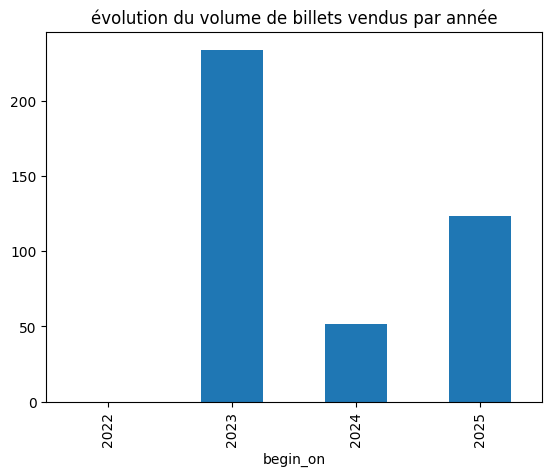

In [14]:
# Âge du client au moment de l’achat
data["age_event"] = (data["date_creation"] - data["DDN"]).dt.days//365 
# Anticipation
data["anticipation"] = (data["begin_on"] - data["date_creation"]).dt.days//365 
# année et mois du début de l'événement
begin_on_year = data["begin_on"].dt.year
begin_on_month = data["begin_on"].dt.month
# Dans quelle salle la dépense moyenne par client est la plus élevée
data.groupby("Lieu")["prix"].mean().sort_values(ascending=False)
# En pourcentage, quelle est l’évolution du volume de billet vendue par année?
df_sales_years = data.groupby(begin_on_year).size()
df_plot = df_sales_years.pct_change()*100
df_sales_years.head()
df_plot.plot(kind="bar")
plt.title("évolution du volume de billets vendus par année")

In [15]:
# la durée d’anticipation médiane d’achat pour l’année 2025?
median_anticipation_2025 = data[(begin_on_year == 2025)]["anticipation"].median()
median_anticipation_2025

np.float64(-1.0)

la valeur -1 trouvée est due par le fait des personnes ont acheté après le début de l'évènement.

In [16]:
# Dans quelle ville la moyenne d’âge des participants au moment de l’évènement est le plus élevé?
df_without_doublon = data[["source", "ville", "id_client", "age_event"]].drop_duplicates()
df_without_doublon.groupby("ville")["age_event"].mean().sort_values(ascending=False)

ville
Paris     23.229851
Nantes    21.705706
Lille     21.155782
Name: age_event, dtype: float64

### Aggrégation aux clients


In [17]:
# Dpenses totale et moyenne apr client
data.groupby("id_client").agg(dep_totale = ("prix", "sum"), dep_moyen = ("prix", "mean"), nbr_billets = ("id_billet", "count"))

,dep_totale,dep_moyen,nbr_billets
id_client,,,
0,14.01,14.010000,1
1,17.99,17.990000,1
10,19.98,9.990000,2
100,34.00,17.000000,2
1001,52.39,17.463333,3
...,...,...,...
994,14.81,14.810000,1
995,35.98,17.990000,2
996,29.98,14.990000,2


In [18]:
# # Nombre de tickets achetés
# data.groupby("id_client").agg(nbr_billets = ("id_billet", "count"))

In [19]:
# # Nombre de commandes effectués
# data.groupby("id_client").agg(nbr_commandes = ("id_billet", "count"))


In [20]:
# calcul des montants clients
df_clients = (data
              .groupby("id_client")
              .agg(nbr_billets = ("id_billet", "count"),
                   DDN_max = ("DDN", "max"),
                   sexe_mode = ("sexe", lambda x: x.mode().iloc[0]),
                   prix_totale = ("prix", "sum"),
                   nbr_commandes = ("id_billet", "count"),
                   nb_source = ("source", "count")
                   )
              )
df_clients.head()

,nbr_billets,DDN_max,sexe_mode,prix_totale,nbr_commandes,nb_source
id_client,,,,,,
0,1,2003-05-24,F,14.01,1,1
1,1,2003-05-24,M,17.99,1,1
10,2,2003-05-24,F,19.98,2,2
100,2,1999-11-13,M,34.00,2,2
1001,3,2003-01-01,F,52.39,3,3
